In [7]:
import pandas as pd # For data handling (loading and manipulating the dataset)
import numpy as np
import matplotlib.pyplot as plt   # For plotting graphs and charts
from sklearn.model_selection import train_test_split   # For splitting data into train and test sets
from sklearn.linear_model import LogisticRegression   # Logistic Regression model
from sklearn.metrics import accuracy_score, classification_report   # To evaluate model performance
from imblearn.over_sampling import RandomOverSampler   # To balance dataset classes (oversampling)import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

In [8]:
df = pd.read_csv("Popular_Spotify_Songs (1).csv", encoding="latin1")  # Ladda dataset
df.head()  # Visa de första 5 raderna

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


Top correlations with in_spotify_playlists:
in_spotify_playlists    1.000000
in_apple_playlists      0.708277
in_apple_charts         0.271317
in_spotify_charts       0.164331
in_deezer_charts        0.144342
energy_%                0.033808
bpm                    -0.019598
valence_%              -0.021883
instrumentalness_%     -0.028134
liveness_%             -0.046695
Name: in_spotify_playlists, dtype: float64

Lowest correlations:
valence_%            -0.021883
instrumentalness_%   -0.028134
liveness_%           -0.046695
acousticness_%       -0.064421
released_day         -0.079669
speechiness_%        -0.089722
artist_count         -0.101966
released_month       -0.104757
danceability_%       -0.106534
released_year        -0.392204
Name: in_spotify_playlists, dtype: float64


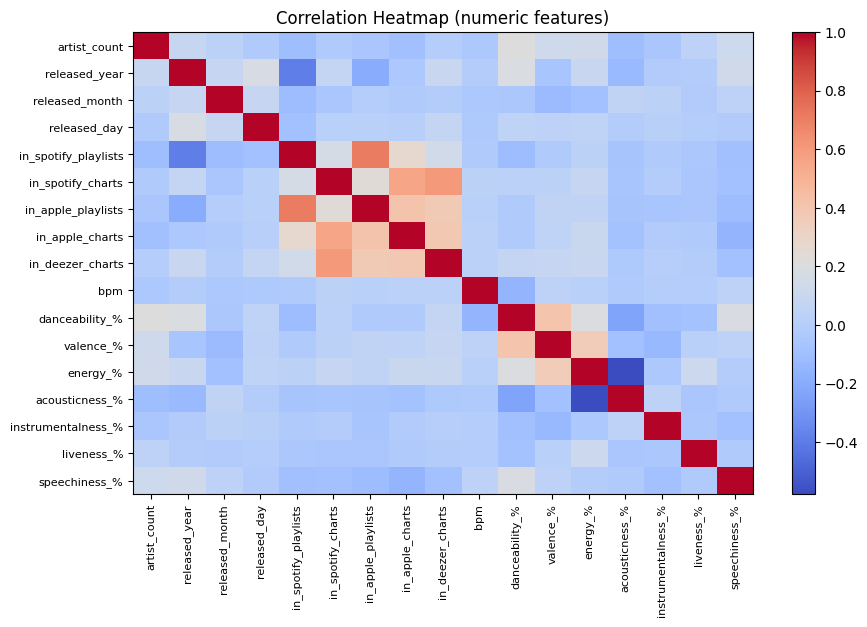

In [9]:
# Lista numeriska kolumner
num_cols = df.select_dtypes(include=[float, int]).columns.tolist()

# Korrelation med "in_spotify_playlists"
corr = df[num_cols].corr(numeric_only=True)["in_spotify_playlists"].sort_values(ascending=False)

print("Top correlations with in_spotify_playlists:")
print(corr.head(10))
print("\nLowest correlations:")
print(corr.tail(10))

# Rita heatmap
plt.figure(figsize=(10,6))
plt.imshow(df[num_cols].corr(numeric_only=True), cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.title("Correlation Heatmap (numeric features)")
plt.xticks(range(len(num_cols)), num_cols, rotation=90, fontsize=8)
plt.yticks(range(len(num_cols)), num_cols, fontsize=8)
plt.show()

In [12]:
def label_by_threshold(threshold):  # Funktion för att skapa target
    return df["in_spotify_playlists"].apply(lambda x: "populär" if x >= threshold else "inte populär")

for thr in [3000, 5000, 7000]:
    y_tmp = label_by_threshold(thr)
    print(f"\nThreshold={thr}")
    print(y_tmp.value_counts(normalize=True).round(3))  # Andelar populär/inte populär


Threshold=3000
in_spotify_playlists
inte populär    0.6
populär         0.4
Name: proportion, dtype: float64

Threshold=5000
in_spotify_playlists
inte populär    0.726
populär         0.274
Name: proportion, dtype: float64

Threshold=7000
in_spotify_playlists
inte populär    0.794
populär         0.206
Name: proportion, dtype: float64


Train set distribution:
in_spotify_playlists
inte populär    553
populär         209
Name: count, dtype: int64

Train set share (%):
in_spotify_playlists
inte populär    0.726
populär         0.274
Name: proportion, dtype: float64


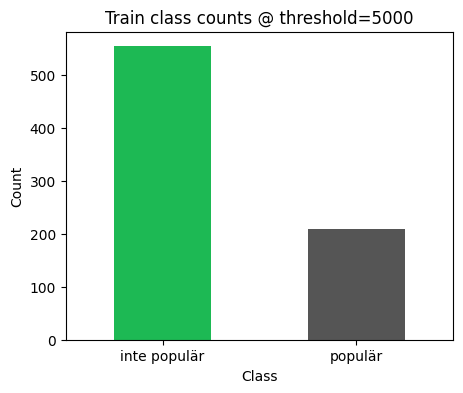

In [13]:
y_5000 = label_by_threshold(5000)  # Target vid threshold=5000

# Train/test split med stratify för att behålla balans
X = df[["bpm","danceability_%","valence_%","energy_%","acousticness_%","instrumentalness_%","liveness_%","speechiness_%"]]
Xtr, Xte, ytr, yte = train_test_split(X, y_5000, test_size=0.2, random_state=42, stratify=y_5000)

print("Train set distribution:")
print(ytr.value_counts())
print("\nTrain set share (%):")
print(ytr.value_counts(normalize=True).round(3))

# Rita bar chart
plt.figure(figsize=(5,4))
ytr.value_counts().plot(kind="bar", color=["#1DB954","#555"])
plt.title("Train class counts @ threshold=5000")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Baseline accuracy: 0.7277486910994765
Baseline macro-F1: 0.4212121212121212

Classification Report (Baseline):
               precision    recall  f1-score   support

inte populär       0.73      1.00      0.84       139
     populär       0.00      0.00      0.00        52

    accuracy                           0.73       191
   macro avg       0.36      0.50      0.42       191
weighted avg       0.53      0.73      0.61       191



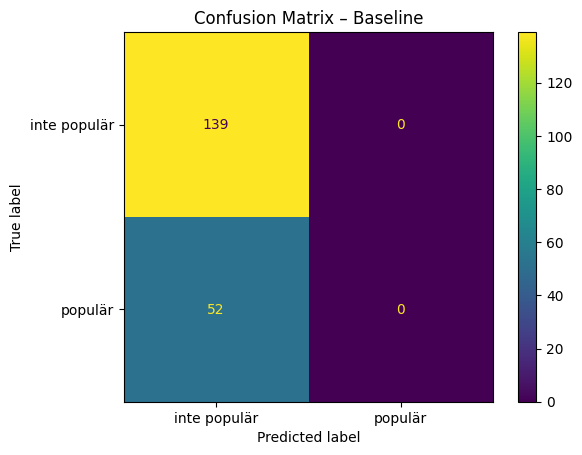

In [14]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(Xtr, ytr)  # Träna modellen

yhat_base = baseline_model.predict(Xte)  # Prediktioner

print("Baseline accuracy:", accuracy_score(yte, yhat_base))
print("Baseline macro-F1:", f1_score(yte, yhat_base, average="macro"))
print("\nClassification Report (Baseline):\n", classification_report(yte, yhat_base, zero_division=0))

ConfusionMatrixDisplay.from_predictions(yte, yhat_base, labels=["inte populär","populär"])
plt.title("Confusion Matrix – Baseline")
plt.show()

Plots

Oversampled accuracy: 0.6028880866425993
Oversampled macro-F1: 0.6001312335958005

Classification Report (Oversampled):
               precision    recall  f1-score   support

inte populär       0.63      0.52      0.57       139
     populär       0.59      0.69      0.63       138

    accuracy                           0.60       277
   macro avg       0.61      0.60      0.60       277
weighted avg       0.61      0.60      0.60       277



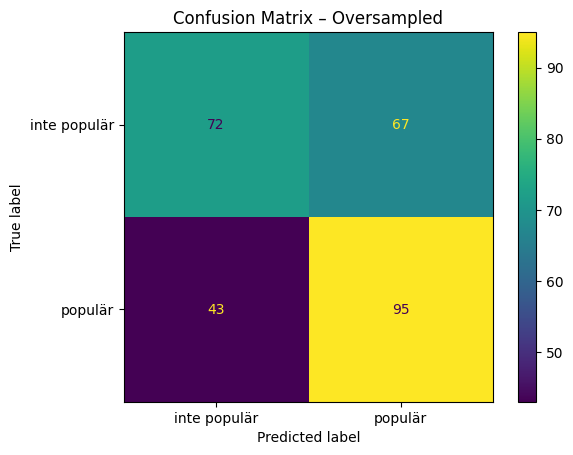

In [15]:
oversampler = RandomOverSampler(random_state=42)
X_res, y_res = oversampler.fit_resample(X, y_5000)

Xtr_o, Xte_o, ytr_o, yte_o = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

model_os = LogisticRegression(max_iter=1000, random_state=42)
model_os.fit(Xtr_o, ytr_o)

yhat_os = model_os.predict(Xte_o)

print("Oversampled accuracy:", accuracy_score(yte_o, yhat_os))
print("Oversampled macro-F1:", f1_score(yte_o, yhat_os, average="macro"))
print("\nClassification Report (Oversampled):\n", classification_report(yte_o, yhat_os, zero_division=0))

ConfusionMatrixDisplay.from_predictions(yte_o, yhat_os, labels=["inte populär","populär"])
plt.title("Confusion Matrix – Oversampled")
plt.show()